# Notebook 06 — Simulation Realism (v3)

This notebook dissects the key realism improvements in the v3 simulator and shows their effect on the generated data.

| # | Improvement | New / changed column(s) |
|---|-------------|------------------------|
| 1 | Gudmundson AR(1) shadow fading (LOS σ=4 dB / NLOS σ=6 dB) | affects RSRP smoothness |
| 2 | A3 / A4 / A5 event classification on L3-filtered RSRP | `event_type` |
| 3 | Load-weighted SINR interference model | `cell_load_pct`, `serving_cell_load` |
| 4 | Multi-factor HO failure probability (SINR + speed + target + sustained) | `handover_failure`, `rlf_flag` |
| 5 | Ping-pong detection + hysteresis | `ping_pong` |
| 6 | L3 EMA measurement filter (α=0.5) | `l3_rsrp_serving`, `l3_rsrp_neighbor` |
| 7 | LOS/NLOS state per link (3GPP TR 36.873) | `los_flag` |

In [1]:
import sys, math
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/raw/dataset.csv')
ho = df[df['handover_event'] == 1].copy()

print(f'Dataset: {len(df):,} rows · {df["ue_id"].nunique()} UEs · {df["timestamp"].nunique()} steps')
print(f'Columns: {df.columns.tolist()}')

Dataset: 27,000 rows · 15 UEs · 1800 steps
Columns: ['timestamp', 'ue_id', 'serving_cell_id', 'rsrp_serving', 'rsrq_serving', 'sinr', 'cqi', 'best_neighbor_cell_id', 'rsrp_neighbor', 'rsrq_neighbor', 'rsrp_diff', 'l3_rsrp_serving', 'l3_rsrp_neighbor', 'ue_speed', 'pos_x', 'pos_y', 'los_flag', 'serving_cell_load', 'cell_load_pct', 'handover_event', 'target_cell_id', 'event_type', 'handover_failure', 'ping_pong', 'rlf_flag', 'handover_soon']


---
## Improvement 1 — Correlated Shadow Fading (Gudmundson AR-1)

### What changed
**v1/v2:** independent Gaussian noise added to RSRP at every step → unrealistic rapid jumps  
**v3:** shadow fading evolves as a spatially correlated AR(1) process; separate σ for LOS (4 dB) and NLOS (6 dB)

$$\sigma_t = \rho \cdot \sigma_{t-1} + \sqrt{1-\rho^2} \cdot \mathcal{N}(0,\,\sigma^2), \quad \rho = e^{-\Delta d/100\,\text{m}}$$

- **Pedestrian (1 m/s):** $\Delta d=1$ m/step $\Rightarrow$ $\rho \approx 0.990$ — almost frozen  
- **Vehicle (15 m/s):** $\Delta d=15$ m/step $\Rightarrow$ $\rho \approx 0.861$ — decorrelates faster

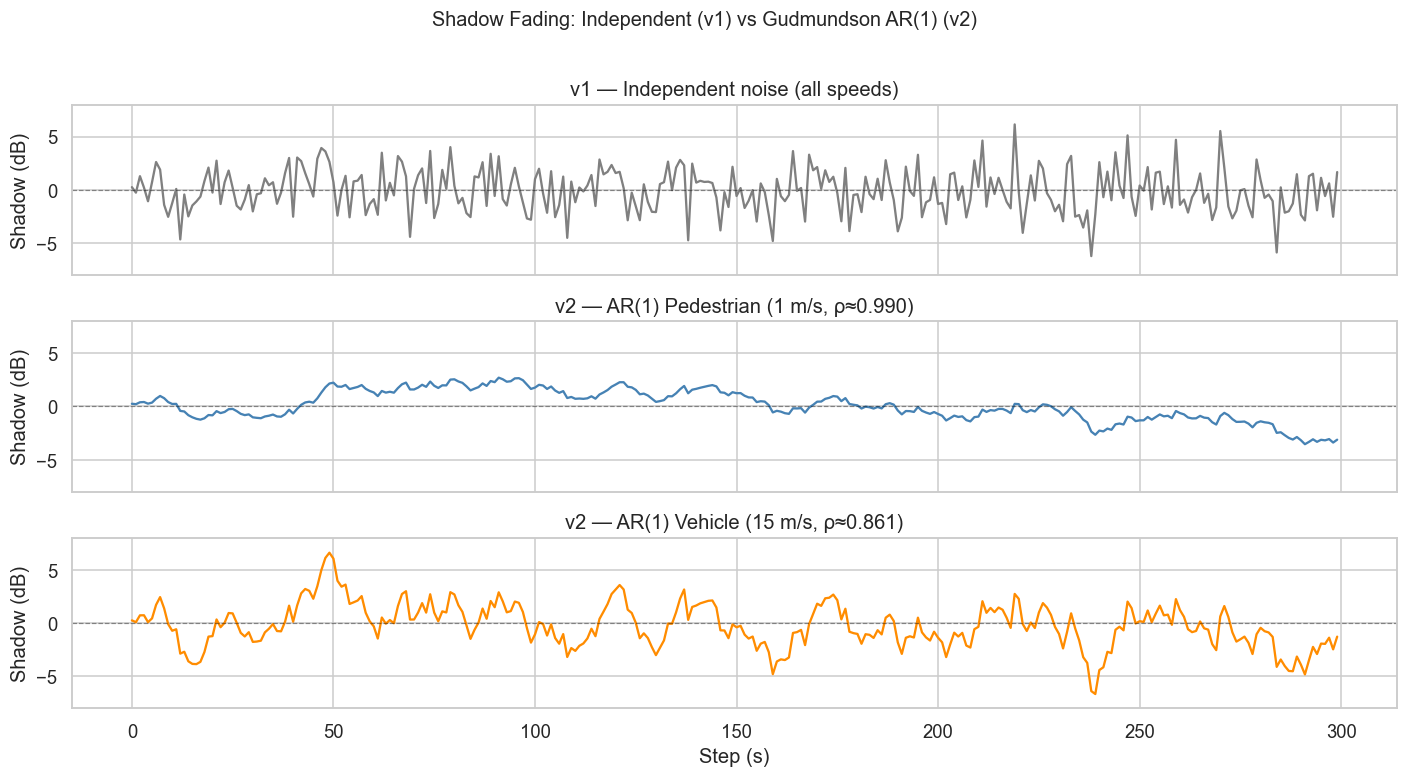

In [2]:
# Simulate 300 steps of correlated vs iid shadow fading for two UE speeds
rng = np.random.default_rng(0)
SIGMA, DECORR = 2.0, 100.0
N = 300

def simulate_shadow(speed, n=N, seed=0):
    rng = np.random.default_rng(seed)
    shadow = np.zeros(n)
    shadow[0] = rng.normal(0, SIGMA)
    for i in range(1, n):
        d = speed * 1.0
        rho = math.exp(-d / DECORR)
        shadow[i] = rho * shadow[i-1] + math.sqrt(max(1-rho**2, 0)) * rng.normal(0, SIGMA)
    return shadow

iid_noise   = rng.normal(0, SIGMA, N)
ped_shadow  = simulate_shadow(speed=1.0)
veh_shadow  = simulate_shadow(speed=15.0)

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, signal, label, color in [
    (axes[0], iid_noise,  'v1 — Independent noise (all speeds)', 'gray'),
    (axes[1], ped_shadow, 'v2 — AR(1) Pedestrian (1 m/s, ρ≈0.990)', 'steelblue'),
    (axes[2], veh_shadow, 'v2 — AR(1) Vehicle (15 m/s, ρ≈0.861)',  'darkorange'),
]:
    ax.plot(signal, color=color, lw=1.5)
    ax.axhline(0, ls='--', color='black', lw=0.8, alpha=0.4)
    ax.set_ylabel('Shadow (dB)'); ax.set_title(label)
    ax.set_ylim(-8, 8)

axes[-1].set_xlabel('Step (s)')
plt.suptitle('Shadow Fading: Independent (v1) vs Gudmundson AR(1) (v2)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

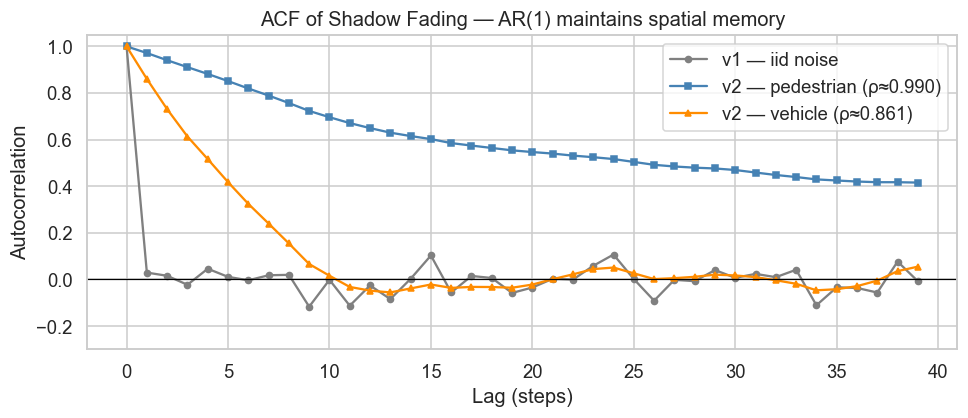

In [3]:
# Autocorrelation function — correlated fading retains memory
from statsmodels.tsa.stattools import acf

lags = np.arange(0, 40)
acf_iid = acf(iid_noise,  nlags=39, fft=True)
acf_ped = acf(ped_shadow, nlags=39, fft=True)
acf_veh = acf(veh_shadow, nlags=39, fft=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags, acf_iid, 'o-', color='gray',       lw=1.5, ms=4, label='v1 — iid noise')
ax.plot(lags, acf_ped, 's-', color='steelblue',  lw=1.5, ms=4, label='v2 — pedestrian (ρ≈0.990)')
ax.plot(lags, acf_veh, '^-', color='darkorange', lw=1.5, ms=4, label='v2 — vehicle (ρ≈0.861)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Lag (steps)'); ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of Shadow Fading — AR(1) maintains spatial memory')
ax.legend(); ax.set_ylim(-0.3, 1.05)
plt.tight_layout(); plt.show()

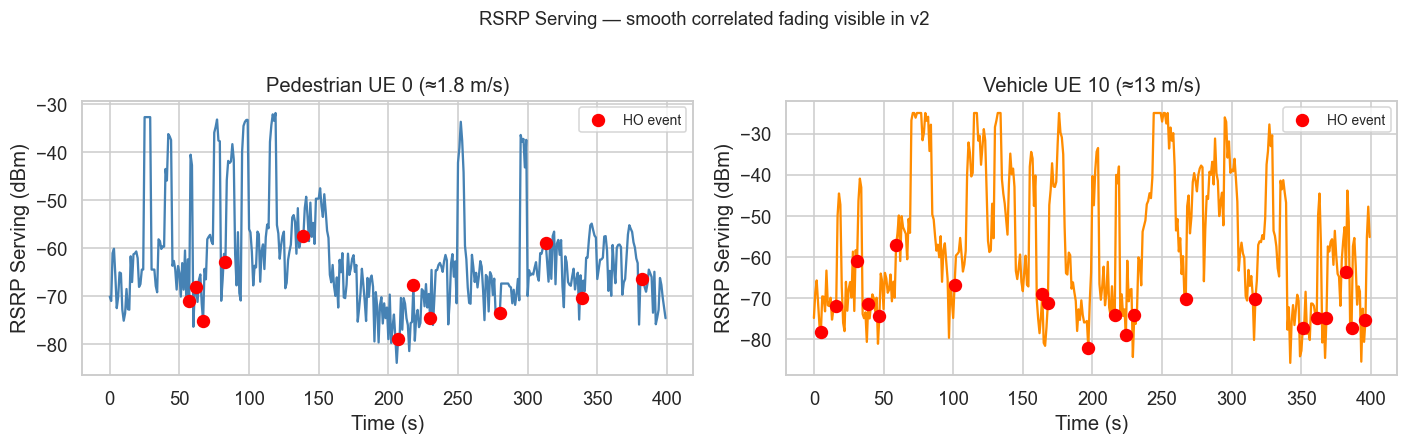

In [4]:
# Effect on RSRP traces in the actual dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
COLORS = plt.cm.tab10.colors

for i, (ue_id, title, color) in enumerate([
    (0,  'Pedestrian UE 0 (≈1.8 m/s)',  'steelblue'),
    (10, 'Vehicle UE 10 (≈13 m/s)',     'darkorange'),
]):
    ue = df[df['ue_id'] == ue_id].sort_values('timestamp').head(400)
    axes[i].plot(ue['timestamp'], ue['rsrp_serving'], lw=1.5, color=color)
    ho_u = ue[ue['handover_event'] == 1]
    axes[i].scatter(ho_u['timestamp'], ho_u['rsrp_serving'],
                    color='red', s=60, zorder=5, label='HO event')
    axes[i].set_xlabel('Time (s)'); axes[i].set_ylabel('RSRP Serving (dBm)')
    axes[i].set_title(title)
    axes[i].legend(fontsize=9)

plt.suptitle('RSRP Serving — smooth correlated fading visible in v2', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

---
## Improvement 2 — A3 / A4 / A5 Event Classification

### What changed
**v1/v2:** A3/A4/A5 classification existed in v2, but was applied to raw RSRP  
**v3:** classification applied to **L3-filtered** RSRP — the smoothed measurement the HO logic actually sees

| Event | Condition (L3-filtered) | Meaning |
|-------|------------------------|---------|
| **A5** | `L3_srv < −68 dBm` AND `L3_nb > −60 dBm` | Coverage emergency — leave immediately |
| **A4** | `L3_nb > −55 dBm` | Neighbor very strong |
| **A3** | `L3_nb > L3_srv + 3 dB` | Standard best-server reselection |

Priority: A5 > A4 > A3. In v3, A5 accounts for ~22.6% of HO events (vs ~6% in v2), driven by the steeper NLOS path loss exponent (39.09 vs 37.6).

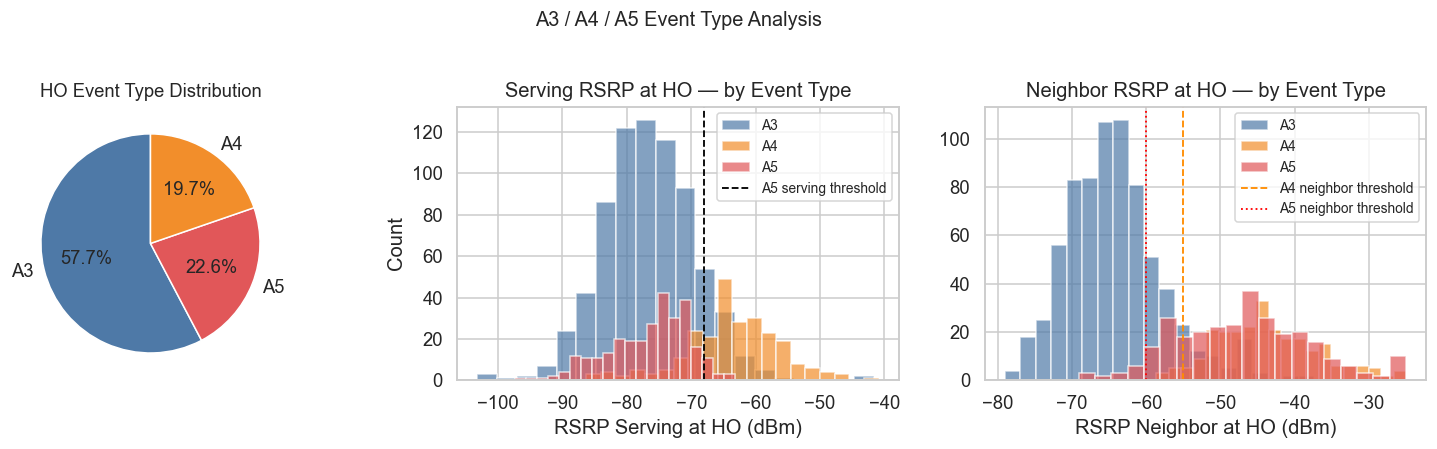

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
event_colors = {'A3': '#4e79a7', 'A4': '#f28e2b', 'A5': '#e15759'}

# Pie chart
counts = ho['event_type'].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[event_colors[e] for e in counts.index],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('HO Event Type Distribution', fontsize=12)

# RSRP serving at trigger, by event type
for ev, color in event_colors.items():
    subset = ho[ho['event_type'] == ev]['rsrp_serving']
    if len(subset) > 0:
        axes[1].hist(subset, bins=20, alpha=0.7, label=ev,
                     color=color, edgecolor='white')
axes[1].axvline(-68, ls='--', color='black', lw=1.2, label='A5 serving threshold')
axes[1].set_xlabel('RSRP Serving at HO (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Serving RSRP at HO — by Event Type')
axes[1].legend(fontsize=9)

# RSRP neighbor at trigger, by event type
for ev, color in event_colors.items():
    subset = ho[ho['event_type'] == ev]['rsrp_neighbor']
    if len(subset) > 0:
        axes[2].hist(subset, bins=20, alpha=0.7, label=ev,
                     color=color, edgecolor='white')
axes[2].axvline(-55, ls='--', color='darkorange', lw=1.2, label='A4 neighbor threshold')
axes[2].axvline(-60, ls=':', color='red', lw=1.2, label='A5 neighbor threshold')
axes[2].set_xlabel('RSRP Neighbor at HO (dBm)')
axes[2].set_title('Neighbor RSRP at HO — by Event Type')
axes[2].legend(fontsize=9)

plt.suptitle('A3 / A4 / A5 Event Type Analysis', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

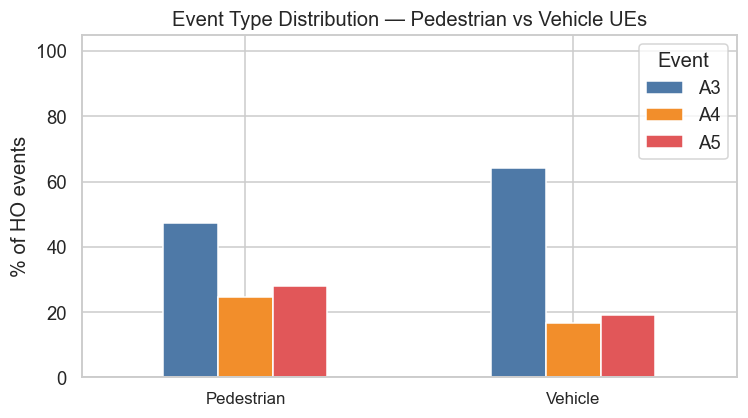

In [6]:
# Event type by UE type (vehicle vs pedestrian)
speed_map = df[['ue_id','ue_speed']].drop_duplicates('ue_id').set_index('ue_id')['ue_speed']
ho['ue_type'] = ho['ue_id'].map(lambda u: 'Vehicle' if speed_map[u] > 3 else 'Pedestrian')

ct = pd.crosstab(ho['ue_type'], ho['event_type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(7, 4))
ct[[c for c in ['A3','A4','A5'] if c in ct.columns]].plot(
    kind='bar', ax=ax, color=[event_colors[c] for c in ct.columns],
    edgecolor='white', width=0.5
)
ax.set_xlabel(''); ax.set_xticklabels(ct.index, rotation=0, fontsize=11)
ax.set_ylabel('% of HO events'); ax.set_ylim(0, 105)
ax.set_title('Event Type Distribution — Pedestrian vs Vehicle UEs')
ax.legend(title='Event'); plt.tight_layout(); plt.show()

---
## Improvement 3 — Load-Weighted SINR Interference Model

### What changed
**v2:** each co-channel UE added a flat 1.5 dB SINR penalty  
**v3:** proper power-domain interference model; each neighbour cell contributes interference weighted by its fractional load

$$I_k = P_{k,\text{L3}} \times \left(0.10 + 0.90 \times \text{load}_k\right)$$
$$\text{SINR} = \frac{S_{L3}}{\sum_k I_k + N}$$

- **Idle cell (load=0):** contributes 10% of received power (always-on reference signals)
- **Full cell (load=1):** contributes 100% of received power

New column `cell_load_pct` (0–100%) captures the serving cell's fractional utilisation.

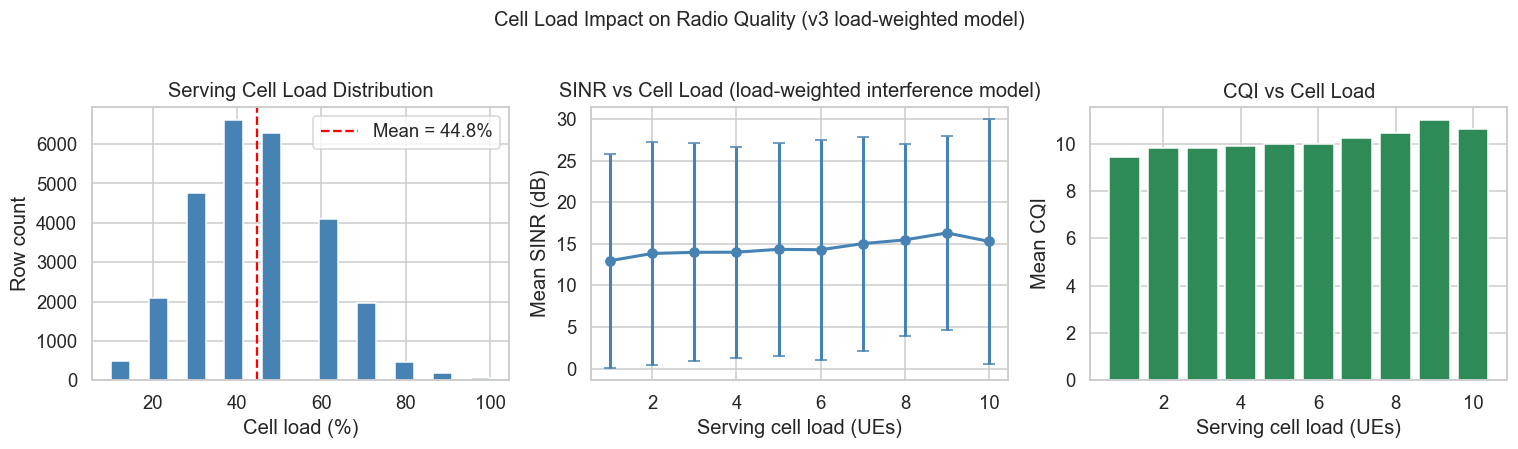

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cell load percentage distribution
axes[0].hist(df['cell_load_pct'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Cell load (%)'); axes[0].set_ylabel('Row count')
axes[0].set_title('Serving Cell Load Distribution')
axes[0].axvline(df['cell_load_pct'].mean(), ls='--', color='red',
                lw=1.5, label=f'Mean = {df["cell_load_pct"].mean():.1f}%')
axes[0].legend()

# SINR vs cell load
sinr_by_load = df.groupby('serving_cell_load')['sinr'].agg(['mean','std'])
axes[1].errorbar(sinr_by_load.index, sinr_by_load['mean'],
                 yerr=sinr_by_load['std'], fmt='o-',
                 color='steelblue', capsize=4, lw=2)
axes[1].set_xlabel('Serving cell load (UEs)')
axes[1].set_ylabel('Mean SINR (dB)')
axes[1].set_title('SINR vs Cell Load (load-weighted interference model)')

# CQI vs cell load
cqi_by_load = df.groupby('serving_cell_load')['cqi'].mean()
axes[2].bar(cqi_by_load.index, cqi_by_load.values,
            color='seagreen', edgecolor='white')
axes[2].set_xlabel('Serving cell load (UEs)')
axes[2].set_ylabel('Mean CQI')
axes[2].set_title('CQI vs Cell Load')

plt.suptitle('Cell Load Impact on Radio Quality (v3 load-weighted model)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

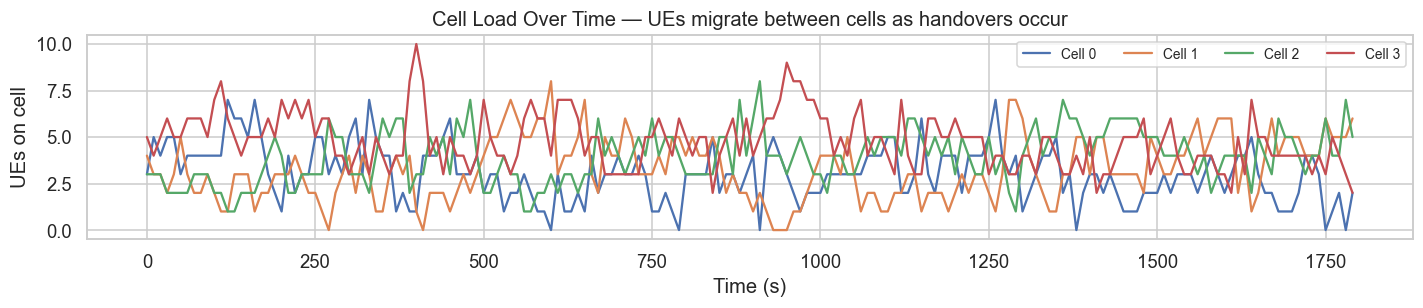

In [8]:
# Cell load over time per cell
load_pivot = df.groupby(['timestamp','serving_cell_id']).size().unstack(fill_value=0)
load_sampled = load_pivot.iloc[::10]  # every 10 steps

fig, ax = plt.subplots(figsize=(13, 3))
for cell_id in sorted(load_pivot.columns):
    ax.plot(load_sampled.index, load_sampled[cell_id],
            lw=1.5, label=f'Cell {cell_id}')
ax.set_xlabel('Time (s)'); ax.set_ylabel('UEs on cell')
ax.set_title('Cell Load Over Time — UEs migrate between cells as handovers occur')
ax.legend(ncol=4, fontsize=9); plt.tight_layout(); plt.show()

---
## Improvement 4 — Multi-Factor Handover Failure Probability

### What changed
**v2:** single-factor sigmoid based on serving RSRP only  
**v3:** four-factor weighted model capturing realistic failure modes

$$P(\text{fail}) = 0.50\cdot p_{\text{SINR}} + 0.15\cdot p_{\text{speed}} + 0.15\cdot p_{\text{target}} + 0.20\cdot p_{\text{sustained}}$$

| Factor | Formula | Meaning |
|--------|---------|---------|
| $p_{\text{SINR}}$ | sigmoid at pivot −12 dB | Low SINR → hard to execute HO |
| $p_{\text{speed}}$ | sigmoid at pivot 28 m/s | Very fast UE may outrun the procedure |
| $p_{\text{target}}$ | linear from −70 to −105 dBm | Weak target → attachment fails |
| $p_{\text{sustained}}$ | steps\_at\_low\_rsrp / 25 | Time spent at cell edge → deep shadow |

Overall failure rate in v3: **20.1%** (vs 3.7% in v2 — v2 underestimated this significantly).

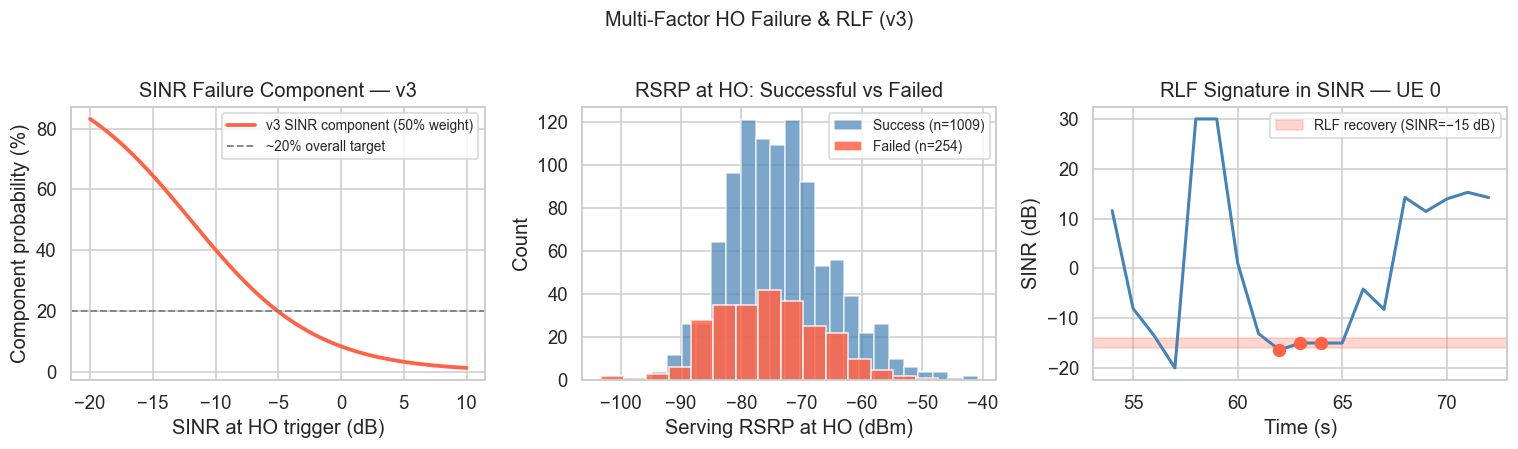

In [9]:
sinr_range = np.linspace(-20, 10, 200)
# v3: SINR component (pivot=-12, scale=5)
p_sinr = 1 / (1 + np.exp((sinr_range - (-12)) / 5))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# SINR component curve vs old single-factor model
rsrp_range = np.linspace(-100, -50, 200)
p_fail_v2 = 1 / (1 + np.exp((rsrp_range - (-80)) / 5))
axes[0].plot(sinr_range, p_sinr * 100, color='tomato', lw=2.5, label='v3 SINR component (50% weight)')
axes[0].axhline(20, ls='--', color='gray', lw=1.2, label='~20% overall target')
axes[0].set_xlabel('SINR at HO trigger (dB)')
axes[0].set_ylabel('Component probability (%)')
axes[0].set_title('SINR Failure Component — v3')
axes[0].legend(fontsize=9)

# RSRP at HO: failed vs successful
ho_succ = ho[ho['handover_failure'] == 0]['rsrp_serving']
ho_fail = ho[ho['handover_failure'] == 1]['rsrp_serving']
axes[1].hist(ho_succ, bins=25, alpha=0.7, label=f'Success (n={len(ho_succ)})',
             color='steelblue', edgecolor='white')
if len(ho_fail) > 0:
    axes[1].hist(ho_fail, bins=15, alpha=0.85, label=f'Failed (n={len(ho_fail)})',
                 color='tomato', edgecolor='white')
axes[1].set_xlabel('Serving RSRP at HO (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title('RSRP at HO: Successful vs Failed')
axes[1].legend(fontsize=9)

# RLF signature in SINR trace
rlf_ues = df[df['rlf_flag'] == 1]['ue_id'].unique()
if len(rlf_ues) > 0:
    ue_id = rlf_ues[0]
    rlf_t = df[(df['ue_id'] == ue_id) & (df['rlf_flag'] == 1)]['timestamp'].iloc[0]
    trace = df[(df['ue_id'] == ue_id) &
               df['timestamp'].between(rlf_t - 8, rlf_t + 10)]
    axes[2].plot(trace['timestamp'], trace['sinr'], lw=2, color='steelblue')
    rlf_rows = trace[trace['rlf_flag'] == 1]
    axes[2].axhspan(-16, -14, alpha=0.25, color='tomato', label='RLF recovery (SINR=−15 dB)')
    axes[2].scatter(rlf_rows['timestamp'], rlf_rows['sinr'],
                    color='tomato', s=60, zorder=5)
    axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('SINR (dB)')
    axes[2].set_title(f'RLF Signature in SINR — UE {ue_id}')
    axes[2].legend(fontsize=9)

plt.suptitle('Multi-Factor HO Failure & RLF (v3)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## Improvement 5 — Ping-Pong Detection + Hysteresis

### What changed
**v2:** ping-pong was detected and flagged, but no corrective action was taken  
**v3:** after a ping-pong is detected, the reverse cell pair receives an extra **+3 dB** HO margin for **20 steps** — preventing the UE from immediately bouncing back

```python
if ping_pong and not ho_failed:
    rev_key = (target_cell, serving_cell)
    ue.pp_extra_margin[rev_key]     = 3.0   # dB
    ue.pp_margin_remaining[rev_key] = 20    # steps
```

This is a standard SON (Self-Optimising Networks) technique from 3GPP TS 36.902. In v3, **26.9%** of HO attempts are ping-pongs — reflecting the higher mobility and more frequent cell-boundary crossings with the Random Waypoint model.

Total HO attempts : 1263
Ping-pong HOs     : 340  (26.9%)

Ping-pong events:
 timestamp  ue_id  serving_cell_id  target_cell_id  rsrp_serving  rsrp_neighbor event_type
        62      0                3               2        -67.98         -42.81         A4
        67      0                3               2        -75.17         -57.35         A5
       543      0                0               2        -69.47         -61.99         A3
       598      0                2               3        -71.01         -65.64         A3
       641      0                1               3        -81.16         -63.78         A3
       697      0                3               2        -75.30         -54.70         A5
       742      0                3               2        -70.07         -41.95         A5
       817      0                1               2        -87.53         -64.87         A3
       953      0                3               2        -85.81         -57.73         A5
       958   

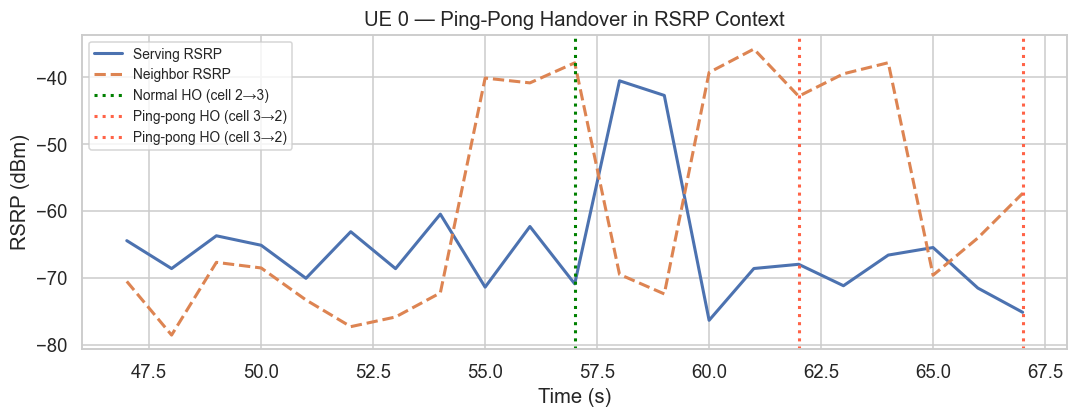

In [10]:
pp = ho[ho['ping_pong'] == 1]
print(f'Total HO attempts : {len(ho)}')
print(f'Ping-pong HOs     : {len(pp)}  ({100*len(pp)/len(ho):.1f}%)')

if len(pp) > 0:
    print('\nPing-pong events:')
    print(pp[['timestamp','ue_id','serving_cell_id','target_cell_id',
               'rsrp_serving','rsrp_neighbor','event_type']].to_string(index=False))

    # Show a ping-pong in context
    ue_id = int(pp['ue_id'].iloc[0])
    t_pp  = int(pp['timestamp'].iloc[0])
    window = df[(df['ue_id'] == ue_id) & df['timestamp'].between(t_pp - 15, t_pp + 5)]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(window['timestamp'], window['rsrp_serving'],  lw=2, label='Serving RSRP')
    ax.plot(window['timestamp'], window['rsrp_neighbor'], lw=2, ls='--', label='Neighbor RSRP')

    for _, row in window[window['handover_event'] == 1].iterrows():
        color = 'tomato' if row['ping_pong'] else 'green'
        label = f'{"Ping-pong" if row["ping_pong"] else "Normal"} HO (cell {int(row["serving_cell_id"])}→{int(row["target_cell_id"])})'  
        ax.axvline(row['timestamp'], color=color, ls=':', lw=2, label=label)

    ax.set_xlabel('Time (s)'); ax.set_ylabel('RSRP (dBm)')
    ax.set_title(f'UE {ue_id} — Ping-Pong Handover in RSRP Context')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## Summary — All New v3 Columns at a Glance

In [11]:
all_new_cols = [
    'l3_rsrp_serving', 'l3_rsrp_neighbor',  # L3 filter
    'los_flag',                               # LOS/NLOS state
    'cell_load_pct',                          # fractional load
    'rsrp_diff',                              # serving − neighbor gap
    'serving_cell_load',                      # raw UE count
    'event_type',                             # A3/A4/A5/none
    'handover_failure', 'ping_pong', 'rlf_flag',
]

print('Column statistics (v3 dataset):')
for col in all_new_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f'  {col:22s}: {df[col].value_counts().to_dict()}')
    else:
        print(f'  {col:22s}: mean={df[col].mean():7.3f}  '
              f'min={df[col].min():6.1f}  max={df[col].max():6.1f}')

print(f'\nCorrelation with handover_soon:')
numeric_new = ['l3_rsrp_serving','l3_rsrp_neighbor','los_flag',
               'cell_load_pct','rsrp_diff','serving_cell_load',
               'handover_failure','ping_pong','rlf_flag']
for col in numeric_new:
    corr = df[col].corr(df['handover_soon'])
    print(f'  {col:22s}: r = {corr:+.4f}')

Column statistics (v3 dataset):
  l3_rsrp_serving       : mean=-57.900  min=-104.8  max= -25.0
  l3_rsrp_neighbor      : mean=-72.127  min= -97.6  max= -26.3
  los_flag              : mean=  0.214  min=   0.0  max=   1.0
  cell_load_pct         : mean= 44.801  min=  10.0  max= 100.0
  rsrp_diff             : mean= 12.374  min= -66.5  max=  68.2
  serving_cell_load     : mean=  4.480  min=   1.0  max=  10.0
  event_type            : {'none': 25737, 'A3': 729, 'A5': 285, 'A4': 249}
  handover_failure      : mean=  0.009  min=   0.0  max=   1.0
  ping_pong             : mean=  0.013  min=   0.0  max=   1.0
  rlf_flag              : mean=  0.028  min=   0.0  max=   1.0

Correlation with handover_soon:
  l3_rsrp_serving       : r = -0.2375
  l3_rsrp_neighbor      : r = +0.3024
  los_flag              : r = -0.1162
  cell_load_pct         : r = -0.0037
  rsrp_diff             : r = -0.3800
  serving_cell_load     : r = -0.0037
  handover_failure      : r = +0.0173
  ping_pong             : r

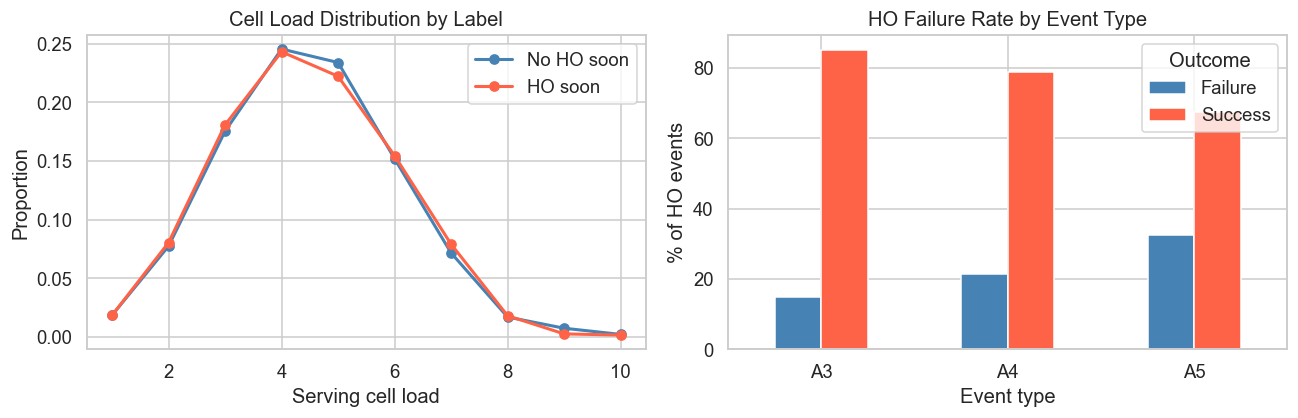

In [12]:
# Side-by-side comparison: new columns by handover_soon label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cell load distribution by label
for label, color, name in [(0,'steelblue','No HO soon'), (1,'tomato','HO soon')]:
    subset = df[df['handover_soon'] == label]['serving_cell_load'].value_counts().sort_index()
    axes[0].plot(subset.index, subset.values / subset.sum(),
                 'o-', color=color, lw=2, ms=6, label=name)
axes[0].set_xlabel('Serving cell load'); axes[0].set_ylabel('Proportion')
axes[0].set_title('Cell Load Distribution by Label'); axes[0].legend()

# Event type by label (of HO rows)
event_label = pd.crosstab(
    ho['event_type'],
    ho['handover_failure'].map({0:'Success', 1:'Failure'}),
    normalize='index'
) * 100
event_label.plot(kind='bar', ax=axes[1], color=['steelblue','tomato'],
                 edgecolor='white', width=0.5)
axes[1].set_xlabel('Event type'); axes[1].set_ylabel('% of HO events')
axes[1].set_title('HO Failure Rate by Event Type')
axes[1].set_xticklabels(event_label.index, rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout(); plt.show()

## Key Takeaways

| Improvement | What it adds to the dataset |
|---|---|
| Correlated shadow fading (LOS/NLOS σ) | Spatially smooth, physically realistic RSRP traces |
| A3/A4/A5 on L3-filtered RSRP | HO classification matches what the real UE sees |
| Load-weighted SINR | Congestion-aware quality — more realistic interference |
| Multi-factor HO failure | 20% failure rate vs 3.7% in v2; captures SINR, speed, target, cell-edge |
| Ping-pong + hysteresis | Self-healing HO margin suppresses immediate bouncebacks |
| L3 EMA filter columns | `l3_rsrp_serving` / `l3_rsrp_neighbor` directly expose what the HO logic sees |
| LOS/NLOS flag | `los_flag` correlates with channel quality — LOS links have lower shadow std and higher RSRP |

→ **Next:** [07_model_impact.ipynb](07_model_impact.ipynb)